# 03 — Fine-tuning de BLIP sobre MIMIC-CXR

Este notebook ejecuta el fine-tuning de BLIP usando `src.models.finetuner`.

La corrida completa debe ejecutarse en GPU, por ejemplo en Kaggle o GCP.

En CPU solo se recomienda correr smoke tests con pocos batches.

**Target de entrenamiento:** se usa `impression`, porque es una conclusión clínica corta y se parece más al estilo de caption generado por BLIP. No usar `findings` como target principal para este fine-tuning.


In [1]:
from pathlib import Path
import os
import sys
import torch

# Detectar raíz del repo de forma robusta:
# - si el notebook se ejecuta desde la raíz, usa Path.cwd()
# - si se ejecuta desde notebooks/, sube un nivel
CWD = Path.cwd()

if (CWD / "src").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "src").exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError(
        "No pude detectar la raíz del repo. "
        "Ejecutá este notebook desde la raíz del proyecto o desde notebooks/."
    )

os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Sin CUDA: usar solo smoke tests en esta máquina.")


Repo root: /home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning
Python: /home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/bin/python
Torch: 2.12.1+cpu
CUDA disponible: False
Sin CUDA: usar solo smoke tests en esta máquina.


In [2]:
from pathlib import Path

MODEL_DIR = Path("models/blip_base")
TRAIN_INDICES = Path("data/splits/train_indices.json")
VAL_INDICES = Path("data/splits/val_indices.json")
TEST_INDICES = Path("data/splits/test_indices.json")
SELECTED_INDICES = Path("data/selected_indices.json")
OUTPUT_DIR = Path("models/blip_finetuned")
CACHE_DIR = Path("data/hf_cache")

paths = {
    "MODEL_DIR": MODEL_DIR,
    "TRAIN_INDICES": TRAIN_INDICES,
    "VAL_INDICES": VAL_INDICES,
    "TEST_INDICES": TEST_INDICES,
    "SELECTED_INDICES": SELECTED_INDICES,
    "OUTPUT_DIR": OUTPUT_DIR,
    "CACHE_DIR": CACHE_DIR,
}

for name, path in paths.items():
    print(f"{name}: {path} -> existe={path.exists()}")

required_paths = [
    TRAIN_INDICES,
    VAL_INDICES,
    TEST_INDICES,
    SELECTED_INDICES,
]

missing = [p for p in required_paths if not p.exists()]

if missing:
    raise FileNotFoundError(f"Faltan archivos requeridos: {missing}")

print("\nPaths principales verificados.")


MODEL_DIR: models/blip_base -> existe=True
TRAIN_INDICES: data/splits/train_indices.json -> existe=True
VAL_INDICES: data/splits/val_indices.json -> existe=True
TEST_INDICES: data/splits/test_indices.json -> existe=True
SELECTED_INDICES: data/selected_indices.json -> existe=True
OUTPUT_DIR: models/blip_finetuned -> existe=False
CACHE_DIR: data/hf_cache -> existe=True

Paths principales verificados.


## 1. Verificación de splits

Antes de entrenar, verificamos que los splits existan, que tengan tamaños razonables, que no se solapen y que `selected_indices.json` esté contenido dentro del split de test.

`selected_indices.json` no debe modificarse, porque contiene las radiografías fijas que se usan para comparar antes y después del fine-tuning.


In [3]:
import json
from pathlib import Path

split_files = {
    "train": Path("data/splits/train_indices.json"),
    "val": Path("data/splits/val_indices.json"),
    "test": Path("data/splits/test_indices.json"),
    "selected": Path("data/selected_indices.json"),
}

splits = {}

for name, path in split_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Falta el archivo requerido: {path}")

    with open(path, "r", encoding="utf-8") as f:
        splits[name] = json.load(f)

print("Tamaños de splits:")
for name, indices in splits.items():
    print(f"{name}: {len(indices)} índices")
    print(f"  primeros 10: {indices[:10]}")
    print(f"  min/max: {min(indices)} / {max(indices)}")
    print()

print("Chequeo de solapamientos:")
pairs = [
    ("train", "val"),
    ("train", "test"),
    ("val", "test"),
    ("selected", "train"),
    ("selected", "val"),
]

for a, b in pairs:
    inter = set(splits[a]) & set(splits[b])
    status = "OK" if len(inter) == 0 else "PROBLEMA"
    print(f"{status}: {a} ∩ {b} = {len(inter)}")

selected_outside_test = set(splits["selected"]) - set(splits["test"])
status = "OK" if len(selected_outside_test) == 0 else "PROBLEMA"
print(f"{status}: selected fuera de test = {len(selected_outside_test)}")

if len(selected_outside_test) > 0:
    raise RuntimeError("selected_indices.json no está contenido en test_indices.json")

print("\nSplits verificados correctamente.")


Tamaños de splits:
train: 24478 índices
  primeros 10: [27366, 14256, 17182, 25009, 6722, 22646, 5364, 1409, 4876, 25748]
  min/max: 0 / 30632

val: 4589 índices
  primeros 10: [12754, 18412, 21227, 30124, 29065, 18432, 24258, 22160, 20211, 30623]
  min/max: 5 / 30627

test: 1531 índices
  primeros 10: [15399, 2454, 5062, 21479, 28570, 13446, 4727, 23700, 502, 14987]
  min/max: 13 / 30604

selected: 30 índices
  primeros 10: [15399, 2454, 5062, 21479, 28570, 13446, 4727, 23700, 502, 14987]
  min/max: 502 / 29658

Chequeo de solapamientos:
OK: train ∩ val = 0
OK: train ∩ test = 0
OK: val ∩ test = 0
OK: selected ∩ train = 0
OK: selected ∩ val = 0
OK: selected fuera de test = 0

Splits verificados correctamente.


## 2. Smoke test local del fine-tuning

Esta celda ejecuta un entrenamiento mínimo de debug usando CPU y pocos batches.

El objetivo no es entrenar el modelo, sino verificar que el notebook puede llamar correctamente a `src.models.finetuner`, que el dataloader funciona y que se genera una loss válida.

En la VM local se debe usar `--device cpu` y `--skip-checkpoint-save`.

La corrida completa se ejecuta después en Kaggle/GCP con `--device cuda`.


In [4]:
import subprocess
import sys
from pathlib import Path

RUN_LOCAL_SMOKE_TEST = True

debug_output_dir = Path("models/blip_finetuned_notebook_debug")

cmd = [
    sys.executable,
    "-m", "src.models.finetuner",
    "--train-indices", "data/splits/train_indices.json",
    "--val-indices", "data/splits/val_indices.json",
    "--output-dir", str(debug_output_dir),
    "--epochs", "1",
    "--batch-size", "1",
    "--device", "cpu",
    "--text-col", "impression",
    "--max-train-batches", "1",
    "--max-val-batches", "1",
    "--skip-checkpoint-save",
]

print("Comando de smoke test:")
print(" ".join(cmd))

if RUN_LOCAL_SMOKE_TEST:
    result = subprocess.run(cmd)

    if result.returncode != 0:
        raise RuntimeError(f"Smoke test falló con returncode={result.returncode}")

    print("\nSmoke test terminado correctamente.")
else:
    print("\nRUN_LOCAL_SMOKE_TEST=False, no se ejecutó el smoke test.")


Comando de smoke test:
/home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/bin/python -m src.models.finetuner --train-indices data/splits/train_indices.json --val-indices data/splits/val_indices.json --output-dir models/blip_finetuned_notebook_debug --epochs 1 --batch-size 1 --device cpu --text-col impression --max-train-batches 1 --max-val-batches 1 --skip-checkpoint-save


INFO __main__: Device seleccionado: cpu
INFO __main__: Cargando modelo desde models/blip_base
INFO src.models.blip_loader: Cargando BLIP desde disco: models/blip_base
Loading weights: 100%|██████████| 471/471 [00:00<00:00, 1689.52it/s]
INFO __main__: Cargando dataset desde cache_dir=data/hf_cache
INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/itsanmolgupta/mimic-cxr-dataset/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/itsanmolgupta/mimic-cxr-dataset/a57188e063c16ba44a35b2d4757351f7626869cf/README.md "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/itsanmolgupta/mimic-cxr-dataset/resolve/a57188e063c16ba44a35b2d4757351f7626869cf/mimic-cxr-dataset.py "HTTP/1.1 404 Not Found"
INF


Smoke test terminado correctamente.


In [5]:
import json
from pathlib import Path

history_path = Path("models/blip_finetuned_notebook_debug/training_history.json")

print("training_history existe:", history_path.exists())

if not history_path.exists():
    raise FileNotFoundError(
        "No se encontró training_history.json. "
        "Primero ejecutá la celda de smoke test."
    )

with open(history_path, "r", encoding="utf-8") as f:
    history = json.load(f)

print("JSON válido:", isinstance(history, list))
print("Cantidad de registros:", len(history))
print(json.dumps(history, indent=2))

if len(history) == 0:
    raise RuntimeError("El historial está vacío.")

last = history[-1]

required_keys = ["epoch", "train_loss", "val_loss", "best_val_loss"]

for key in required_keys:
    if key not in last:
        raise KeyError(f"Falta la clave {key} en training_history.json")

print("\nSmoke test verificado correctamente.")


training_history existe: True
JSON válido: True
Cantidad de registros: 1
[
  {
    "epoch": 1.0,
    "train_loss": 6.049112796783447,
    "val_loss": 6.909502983093262,
    "best_val_loss": 6.909502983093262,
    "trainable_params": 128030780.0,
    "total_params": 223971644.0,
    "trainable_pct": 57.16383454326924
  }
]

Smoke test verificado correctamente.


## 3. Fine-tuning en GPU / Kaggle

Esta sección queda preparada para correr en Kaggle o GCP con CUDA.

En la VM local no debe ejecutarse la corrida completa porque PyTorch está instalado en modo CPU-only.

El flujo recomendado en GPU es:

1. Verificar que CUDA esté disponible.
2. Correr un smoke test GPU con pocos batches.
3. Si el smoke test funciona, correr el fine-tuning completo.
4. Verificar que se haya creado `models/blip_finetuned/best/`.

Para ejecutar en Kaggle, cambiar las variables `RUN_GPU_SMOKE_TEST` y/o `RUN_FULL_TRAINING` a `True`.


In [6]:
import torch
import sys
from pathlib import Path

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA no disponible en este entorno. No correr entrenamiento completo acá.")


Python: /home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/bin/python
Torch: 2.12.1+cpu
CUDA disponible: False
CUDA no disponible en este entorno. No correr entrenamiento completo acá.


In [7]:
import subprocess
import sys
from pathlib import Path

RUN_GPU_SMOKE_TEST = False  # Cambiar a True en Kaggle/GCP

gpu_debug_output_dir = Path("models/blip_finetuned_gpu_debug")

cmd_gpu_smoke = [
    sys.executable,
    "-m", "src.models.finetuner",
    "--train-indices", "data/splits/train_indices.json",
    "--val-indices", "data/splits/val_indices.json",
    "--output-dir", str(gpu_debug_output_dir),
    "--epochs", "1",
    "--batch-size", "2",
    "--device", "cuda",
    "--text-col", "impression",
    "--num-workers", "2",
    "--max-train-batches", "2",
    "--max-val-batches", "1",
    "--skip-checkpoint-save",
]

print("Comando smoke test GPU:")
print(" ".join(cmd_gpu_smoke))

if RUN_GPU_SMOKE_TEST:
    if not torch.cuda.is_available():
        raise RuntimeError("RUN_GPU_SMOKE_TEST=True, pero CUDA no está disponible.")

    result = subprocess.run(cmd_gpu_smoke)

    if result.returncode != 0:
        raise RuntimeError(f"Smoke test GPU falló con returncode={result.returncode}")

    print("\nSmoke test GPU terminado correctamente.")
else:
    print("\nRUN_GPU_SMOKE_TEST=False. No se ejecutó el smoke test GPU.")


Comando smoke test GPU:
/home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/bin/python -m src.models.finetuner --train-indices data/splits/train_indices.json --val-indices data/splits/val_indices.json --output-dir models/blip_finetuned_gpu_debug --epochs 1 --batch-size 2 --device cuda --text-col impression --max-train-batches 2 --max-val-batches 1 --skip-checkpoint-save

RUN_GPU_SMOKE_TEST=False. No se ejecutó el smoke test GPU.


In [8]:
import subprocess
import sys
import torch
from pathlib import Path

RUN_FULL_TRAINING = False  # Cambiar a True solo en Kaggle/GCP con CUDA

full_output_dir = Path("models/blip_finetuned")

cmd_full_training = [
    sys.executable,
    "-m", "src.models.finetuner",
    "--train-indices", "data/splits/train_indices.json",
    "--val-indices", "data/splits/val_indices.json",
    "--output-dir", str(full_output_dir),
    "--epochs", "3",
    "--batch-size", "4",
    "--device", "cuda",
    "--text-col", "impression",
    "--num-workers", "2",
]

print("Comando fine-tuning completo:")
print(" ".join(cmd_full_training))

if RUN_FULL_TRAINING:
    if not torch.cuda.is_available():
        raise RuntimeError("RUN_FULL_TRAINING=True, pero CUDA no está disponible.")

    result = subprocess.run(cmd_full_training)

    if result.returncode != 0:
        raise RuntimeError(f"Fine-tuning completo falló con returncode={result.returncode}")

    print("\nFine-tuning completo terminado correctamente.")
else:
    print("\nRUN_FULL_TRAINING=False. No se ejecutó el entrenamiento completo.")


Comando fine-tuning completo:
/home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/bin/python -m src.models.finetuner --train-indices data/splits/train_indices.json --val-indices data/splits/val_indices.json --output-dir models/blip_finetuned --epochs 3 --batch-size 4 --device cuda --text-col impression

RUN_FULL_TRAINING=False. No se ejecutó el entrenamiento completo.


In [9]:
import json
from pathlib import Path

BEST_DIR = Path("models/blip_finetuned/best")
HISTORY_PATH = Path("models/blip_finetuned/training_history.json")

print("BEST_DIR:", BEST_DIR)
print("BEST_DIR existe:", BEST_DIR.exists())

print("HISTORY_PATH:", HISTORY_PATH)
print("training_history existe:", HISTORY_PATH.exists())

if BEST_DIR.exists():
    print("\nArchivos en best/:")
    for p in sorted(BEST_DIR.iterdir()):
        print(" -", p.name)

if HISTORY_PATH.exists():
    with open(HISTORY_PATH, "r", encoding="utf-8") as f:
        history = json.load(f)

    print("\nRegistros en training_history:", len(history))
    print(json.dumps(history, indent=2))
else:
    print("\nTodavía no hay entrenamiento completo guardado.")


BEST_DIR: models/blip_finetuned/best
BEST_DIR existe: False
HISTORY_PATH: models/blip_finetuned/training_history.json
training_history existe: False

Todavía no hay entrenamiento completo guardado.


## 5. Visualización de la curva de entrenamiento

Esta sección grafica `train_loss` y `val_loss` a partir de `training_history.json`.

Prioridad de lectura:

1. `models/blip_finetuned/training_history.json` si ya se ejecutó el entrenamiento completo.
2. `models/blip_finetuned_notebook_debug/training_history.json` como fallback local de smoke test.

En la VM local probablemente se grafique solo el historial de debug. En Kaggle, después del entrenamiento completo, debería graficarse el historial real.


Usando historial: models/blip_finetuned_notebook_debug/training_history.json
Cantidad de registros: 1
Último registro:
{
  "epoch": 1.0,
  "train_loss": 6.049112796783447,
  "val_loss": 6.909502983093262,
  "best_val_loss": 6.909502983093262,
  "trainable_params": 128030780.0,
  "total_params": 223971644.0,
  "trainable_pct": 57.16383454326924
}


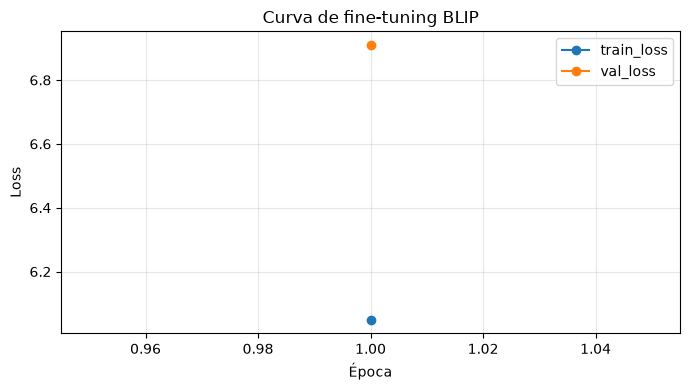

Figura guardada en: outputs/finetuning/loss_curve.png


In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

history_candidates = [
    Path("models/blip_finetuned/training_history.json"),
    Path("models/blip_finetuned_notebook_debug/training_history.json"),
    Path("models/blip_finetuned_gpu_debug/training_history.json"),
]

history_path = next((p for p in history_candidates if p.exists()), None)

if history_path is None:
    print("No se encontró ningún training_history.json todavía.")
    print("Primero ejecutar el smoke test o el entrenamiento completo.")
else:
    print("Usando historial:", history_path)

    with open(history_path, "r", encoding="utf-8") as f:
        history = json.load(f)

    if not isinstance(history, list) or len(history) == 0:
        raise RuntimeError(f"Historial inválido o vacío: {history_path}")

    required_keys = {"epoch", "train_loss", "val_loss"}
    missing_keys = required_keys - set(history[0].keys())

    if missing_keys:
        raise KeyError(f"Faltan claves en training_history.json: {missing_keys}")

    epochs = [row["epoch"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row["val_loss"] for row in history]

    print("Cantidad de registros:", len(history))
    print("Último registro:")
    print(json.dumps(history[-1], indent=2))

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_loss, marker="o", label="train_loss")
    plt.plot(epochs, val_loss, marker="o", label="val_loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Curva de fine-tuning BLIP")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = Path("outputs/finetuning/loss_curve.png")
    output_plot.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_plot, dpi=200, bbox_inches="tight")
    plt.show()

    print("Figura guardada en:", output_plot)


## 6. Sanity check del checkpoint fine-tuneado

Esta sección verifica que `models/blip_finetuned/best/` pueda cargarse y generar un caption sobre una de las radiografías fijas de `data/selected_indices.json`.

En la VM local esta celda probablemente no haga nada porque `best/` todavía no existe.

En Kaggle/GCP, después del entrenamiento completo, debe:

1. Cargar `models/blip_finetuned/best/`.
2. Tomar una imagen de `selected_indices.json`.
3. Generar un caption.
4. Mostrar la referencia `impression`.


In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from src.models.blip_loader import load_model_and_processor
from src.data.utils import load_mimic_dataset

RUN_CHECKPOINT_SANITY = True

best_dir = Path("models/blip_finetuned/best")
selected_path = Path("data/selected_indices.json")
cache_dir = Path("data/hf_cache")

print("best_dir:", best_dir)
print("best_dir existe:", best_dir.exists())

if not RUN_CHECKPOINT_SANITY:
    print("RUN_CHECKPOINT_SANITY=False. No se ejecutó el sanity check.")
elif not best_dir.exists():
    print("Todavía no existe models/blip_finetuned/best/.")
    print("Esto es esperable en la VM local antes de correr el entrenamiento completo en GPU.")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device seleccionado:", device)

    model, processor = load_model_and_processor(
        model_dir=best_dir,
        device=device,
    )

    ds = load_mimic_dataset(cache_dir=str(cache_dir))
    hf_split = ds["train"]

    with open(selected_path, "r", encoding="utf-8") as f:
        selected_indices = json.load(f)

    if len(selected_indices) == 0:
        raise RuntimeError("selected_indices.json está vacío.")

    idx = selected_indices[0]
    sample = hf_split[idx]

    image = sample["image"].convert("RGB")
    reference = sample.get("impression", "")

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=40,
            num_beams=1,
        )

    generated_caption = processor.decode(
        output_ids[0],
        skip_special_tokens=True,
    )

    print("Índice evaluado:", idx)
    print("\nCaption generado por BLIP fine-tuneado:")
    print(generated_caption)

    print("\nImpression de referencia:")
    print(reference)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"idx={idx}")
    plt.show()

    if device == "cuda":
        del model
        torch.cuda.empty_cache()


/home/ubuntu/Documents/Vision Artificial/tp_final_vision/image-captioning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


best_dir: models/blip_finetuned/best
best_dir existe: False
Todavía no existe models/blip_finetuned/best/.
Esto es esperable en la VM local antes de correr el entrenamiento completo en GPU.
